# Random Forest Classifier Model
- Entire VIF normalized dataset model

### Import all the necessary libraries and frameworks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from itertools import product
import shap, joblib, os

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data path to different folders
- Set up all necessary input/output paths
# NOTE: potential redundancy between `IMPORTANCE_DIR` and `importance_dir`


In [2]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
importance_dir = "../data/feature_importance/per_country"
model_dir = "../models/per_country"
metrics_dir = "../data/evaluation_metrics/per_country"
IMPORTANCE_DIR = "../data/feature_importance"
SHAP_DIR = "../data/shap_values"


os.makedirs(importance_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

### Initial setup
- drop_cols: features to exclude from training
- targets: list of recession labels — choose one to train on below
- random_state: ensures reproducibility of model training


In [3]:
drop_cols = ['date', 'Country']
targets = ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD']
random_state = 42

### Load data
- Load the normalized panel dataset
- Ensure 'date' column is in datetime format and that data is sorted chronologically by country


In [4]:
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Country', 'date'])

### Results container
- Initialize results container to track evaluation metrics for the current run


In [5]:
all_results = []

### Target variable
- Set which recession-related outcome we are predicting
- Can swap to 'RECESS' or 'RECESS_PERIOD' to reuse notebook


In [58]:
target = "RECESS_OVER"

### Split the data
- X contains only predictive features — excludes targets and columns like date/country
- y is the label we're training on


In [59]:
X = df.drop(columns=drop_cols + ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD'])
y = df[target]

- Time-based slicing ensures no leakage from future data
- We use a rolling train → val → test setup, mimicking real forecasting


In [61]:
train_start = "1995-01-01"
train_end   = "2009-12-31"
val_end     = "2018-12-31"
test_end    = "2024-05-31"

In [62]:
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
val_mask   = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask  = (df['date'] > val_end) & (df['date'] <= test_end)

### Split feature matrix and target vector into train, val, test subsets

In [63]:
X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]
X_test = X[test_mask]
y_test = y[test_mask]

### Sanity check: confirm size of splits and their date ranges

In [64]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df[train_mask]['date'].min().date()} to {df[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df[val_mask]['date'].min().date()} to {df[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df[test_mask]['date'].min().date()} to {df[test_mask]['date'].max().date()}")

Train: 1080 samples
Validation: 648 samples
Test: 390 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2024-05-01


### Building the model
- Define base model and search grid for hyperparameter tuning
- Balanced class weights handle class imbalance automatically


In [65]:
# Define the base model
base_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=random_state
)

In [66]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

### Build all hyperparameter combinations
- Extract keys/values from the param_grid
- Use itertools.product to generate a full list of parameter combinations


In [67]:
# Build all combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

### Initialize placeholders for the best model
- best_model: store the trained model with highest F1 on validation
- best_f1: the current best F1 score
- best_params: hyperparameters of the best model
- best_thresh: best threshold for converting probabilities to labels

In [68]:
best_model = None
best_f1 = 0
best_params = None
best_thresh = 0.5

### Generate all hyperparameter combos
- For each combo:
    - train model
    - generate probabilities on validation set
    - search for best classification threshold (maximize F1 score)
- Track the best model, threshold, and parameter set

In [69]:
for combo in combinations:
    model = RandomForestClassifier(
        **combo,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)

    # Predict on validation set
    y_val_prob = model.predict_proba(X_val)[:, 1]

    # Threshold tuning on val set
    for t in np.arange(0.1, 0.9, 0.01):
        y_val_pred = (y_val_prob > t).astype(int)
        f1 = f1_score(y_val, y_val_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_params = combo
            best_thresh = t

In [70]:
print("[TUNED] Best F1 on validation set:", best_f1)
print("[TUNED] Best parameters:", best_params)
print("[TUNED] Best threshold:", best_thresh)

[TUNED] Best F1 on validation set: 0.08191126279863481
[TUNED] Best parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
[TUNED] Best threshold: 0.18999999999999995


In [71]:
# Predict on test set with best model + threshold
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > best_thresh).astype(int)

### Evaluate model performance
- Calculate AUC, F1, precision, recall, and accuracy on the test set

In [72]:
# Evaluate
auc = roc_auc_score(y_test, y_test_prob)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)

### Model Performance
- Print all evaluation metrics and the selected threshold

In [73]:
print("Threshold Tuning")
print(f"   Optimal Threshold: {best_thresh:.2f}\n")

print("Evaluation Metrics")
print(f"   AUC       : {auc:.3f}")
print(f"   F1 Score  : {f1:.3f}")
print(f"   Precision : {precision:.3f}")
print(f"   Recall    : {recall:.3f}")
print(f"   Accuracy  : {accuracy:.3f}")


Threshold Tuning
   Optimal Threshold: 0.19

Evaluation Metrics
   AUC       : 0.589
   F1 Score  : 0.167
   Precision : 0.095
   Recall    : 0.690
   Accuracy  : 0.490


### Save the model

In [74]:
joblib.dump(model, f"{model_dir}/RFC_GRID_model_{target}_VIF_full.pkl")

['../models/per_country/RFC_model_RECESS_OVER_VIF_full.pkl']

### Feature Importance
- Extract feature importances from the best model
- Save to CSV for documentation or comparison

In [75]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

importance_path = os.path.join(IMPORTANCE_DIR, f"XGB_{target}_importance.csv")
importances.to_csv(importance_path)

print(importances)
print(f"[INFO] Feature importance saved: {importance_path}")

CCI (Index)_LAG12    0.199065
EPU (Index)_LAG1     0.125409
IP (Index)_LAG6      0.073270
CCI (Index)_LAG3     0.068383
IP (Index)_LAG12     0.060789
EPU (Index)_LAG3     0.054778
YS (%)_LAG12         0.049926
INF (%)_LAG3         0.049348
INF (%)_MA12         0.048070
EPU (Index)_LAG6     0.043137
INF (%)_LAG1         0.037972
IP (Index)_LAG3      0.036401
IP (Index)           0.036265
INF (%)              0.034390
INF (%)_LAG6         0.031734
EPU (Index)_LAG12    0.026764
INF (%)_LAG12        0.024298
dtype: float64
[INFO] Feature importance saved: ../data/feature_importance\XGB_RECESS_OVER_importance.csv


### Use SHAP to interpret model predictions on the training set
- SHAP assigns importance to each feature for each prediction
- The bar plot summarizes which features were most impactful overall


In [76]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

In [77]:
# Extract SHAP values for the positive class (class 1)
shap_array = shap_values.values[:, :, 1]  # shape: (n_samples, n_features)

shap_df = pd.DataFrame(shap_array, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

### Save SHAP bar plot as a PNG image to the metrics directory

In [78]:
shap_path = os.path.join(SHAP_DIR, f"RCF_GRID_SHAP_{target}.csv")
mean_shap.to_csv(shap_path)

print(f"[INFO] SHAP values saved: {shap_path}")

[INFO] SHAP values saved: ../data/shap_values\XGB_SHAP_RECESS_OVER.csv


### Plot of SHAP values that influence recession

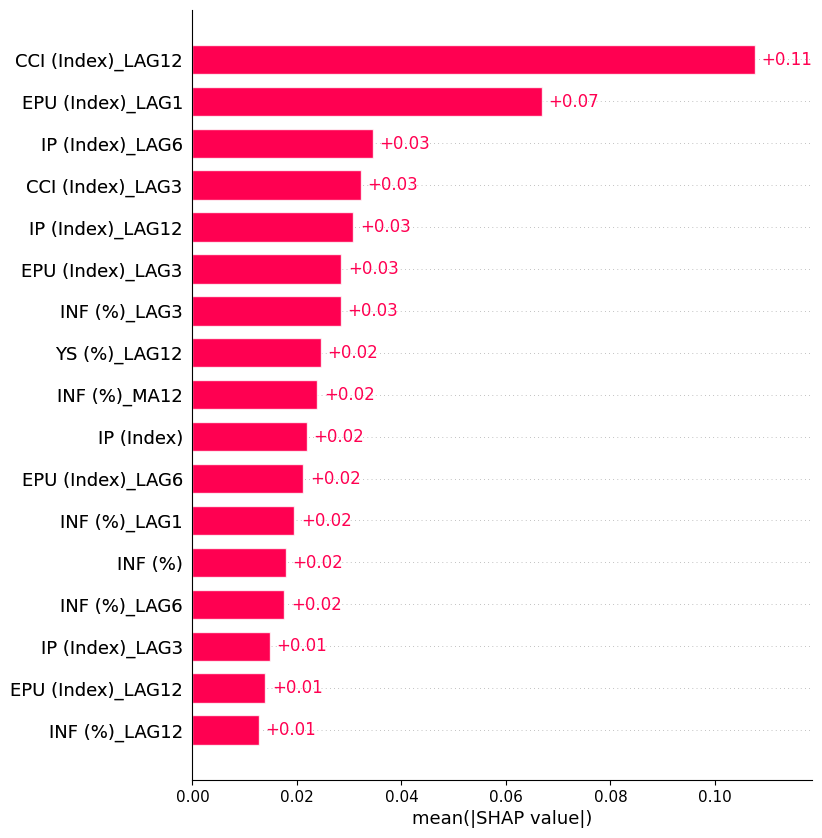

In [79]:
shap_values_class1 = shap_values.values[:, :, 1]

# Create a summary bar plot with top 20 features
shap.plots.bar(
    shap.Explanation(values=shap_values_class1,
                     base_values=shap_values.base_values[:, 1],
                     data=X_train.values,
                     feature_names=X_train.columns),
    max_display=20,
    show=True
)

In [80]:
# Save the current figure
plt.tight_layout()
plt.savefig(f"{metrics_dir}/SHAP_bar_plot_{target}_RFC.png", dpi=300)
plt.close()

### Store the prediction values on a file
- Generate predictions on the test set using the best model and threshold
- Save predicted labels and probabilities to a CSV file for further analysis


In [81]:
# Predict test probabilities and class labels using the best model and threshold
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > best_thresh).astype(int)

# Create the DataFrame
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})

# Save to CSV
pred_df.to_csv(f"../data/SHAP/RFC_predictions_{target}_VIF_full.csv", index=False)

- Record evaluation metrics for the current target
- Convert results into a DataFrame for later viewing/saving


In [82]:
all_results.append({
    "Target": target,
    "AUC": auc,
    "F1": best_f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh
})

results_df = pd.DataFrame(all_results)

### Save the performance
- Save evaluation results for all trained models (per target) to CSV
- Display it for visual confirmation


In [83]:
results_df.to_csv(f"{metrics_dir}/RFC_evaluation_{target}_email_VIF_full.csv", index=False)
results_df

,Target,AUC,F1,Precision,Recall,Accuracy,Threshold
0,RECESS,0.643893,0.641910,0.275676,1.000000,0.312821,0.27
1,RECESS_PERIOD,0.535832,0.149758,0.275148,0.989362,0.369231,0.14
2,RECESS_OVER,0.589455,0.081911,0.095238,0.689655,0.489744,0.19
